In [8]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler

import warnings 

warnings.filterwarnings('ignore')

# Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

DBSCAN groups points based on how closely packed they are, making it ideal for discovering clusters of arbitrary shapes and isolating outliers/noise.

---

### Core Parameters
- **$\epsilon$ (`eps`)**: The maximum radial distance between two samples for one to be considered as in the neighborhood of the other.
- **`min_samples`**: The minimum number of samples in a neighborhood for a point to be designated as a **core point** (including the point itself).

---

### Point Classifications
1. **Core Point**: A point with at least `min_samples` within its $\epsilon$-neighborhood.
2. **Border Point**: A point that has fewer than `min_samples` in its $\epsilon$-neighborhood, but falls within the $\epsilon$-neighborhood of a Core Point.
3. **Noise Point**: Any point that is neither a Core Point nor a Border Point (labeled as `-1` in `scikit-learn`).

---

### Algorithmic Steps
1. **Locate Core Points**: Compute the $\epsilon$-neighborhood for every point and identify all core points.
2. **Find Connected Components**: Connect core points that fall within each other's $\epsilon$-neighborhood to form the backbone of a cluster.
3. **Assign Border Points**: Assign non-core points within $\epsilon$ distance of a cluster to that cluster.
4. **Identify Noise**: Any point not reachable from any core point is marked as noise ($-1$).

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
np.random.seed(42)

n_samples = 600

X_circles, _ = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)

X_moons, _ = make_moons(n_samples=n_samples, noise=0.08, random_state=42)

X_blobs, _ = make_blobs(n_samples=n_samples, centers=[(-2, -2), (2, 2), (0, 3)], cluster_std=[0.4, 0.6, 0.9], random_state=42)

datasets = [
    ("Concentric Circles", StandardScaler().fit_transform(X_circles), {"eps": 0.25, "min_samples": 5, "k": 2}),
    ("Interleaving Moons", StandardScaler().fit_transform(X_moons), {"eps": 0.25, "min_samples": 5, "k": 2}),
    ("Multi-Density Blobs", StandardScaler().fit_transform(X_blobs), {"eps": 0.30, "min_samples": 7, "k": 3}),
]

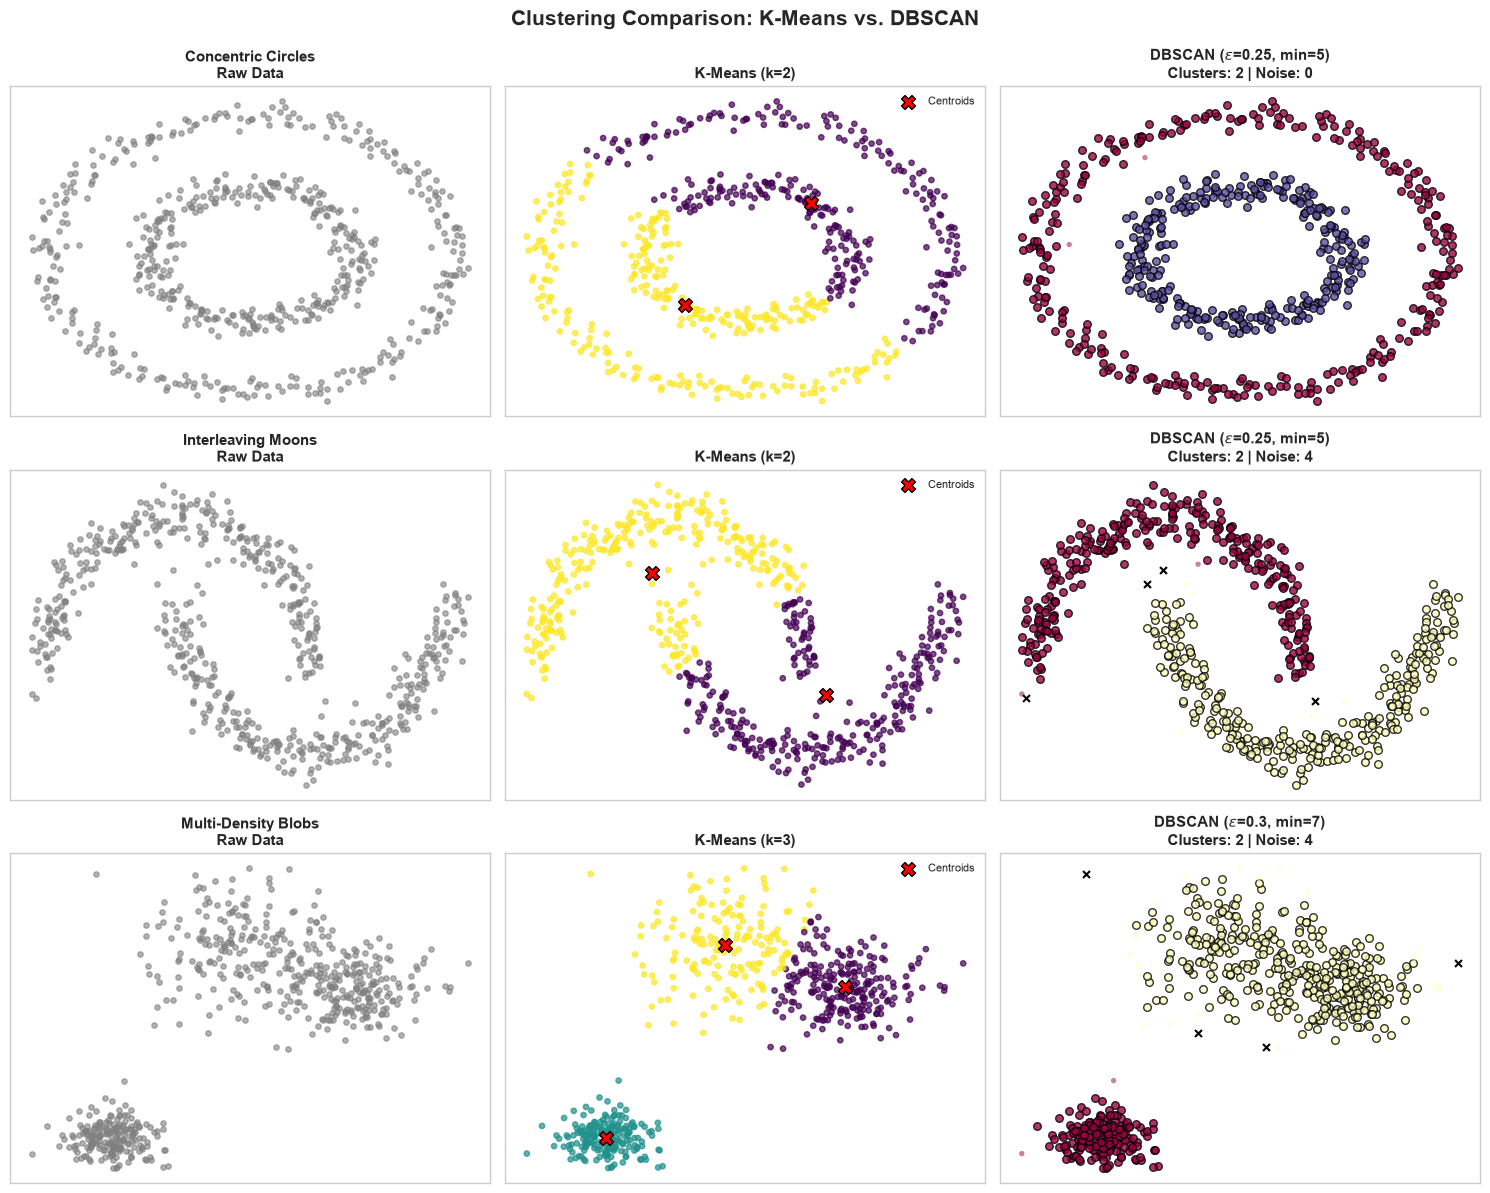

In [9]:
fig, axes = plt.subplots(len(datasets), 3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

for row_idx, (name, X, params) in enumerate(datasets):
    axes[row_idx, 0].scatter(X[:, 0], X[:, 1], c="gray", s=15, alpha=0.6)
    axes[row_idx, 0].set_title(f"{name}\nRaw Data", fontsize=11, fontweight="bold")

    # K Means
    kmeans = KMeans(n_clusters=params["k"], n_init=10, random_state=42)
    kmeans_labels = kmeans.fit_predict(X)
    
    axes[row_idx, 1].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap="viridis", s=15, alpha=0.7)
    # Plot K-Means centroids
    centers = kmeans.cluster_centers_
    axes[row_idx, 1].scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=100, edgecolors="black", label="Centroids")
    axes[row_idx, 1].set_title(f"K-Means (k={params['k']})", fontsize=11, fontweight="bold")
    axes[row_idx, 1].legend(loc="upper right", fontsize=8)

    # DBSCAN
    dbscan = DBSCAN(eps=params["eps"], min_samples=params["min_samples"])
    dbscan_labels = dbscan.fit_predict(X)
    
    # Mask core, border, and noise points
    core_samples_mask = np.zeros_like(dbscan_labels, dtype=bool)
    core_samples_mask[dbscan.core_sample_indices_] = True
    
    unique_labels = set(dbscan_labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black color used for noise
            col = [0, 0, 0, 1]
            class_member_mask = (dbscan_labels == k)
            axes[row_idx, 2].scatter(
                X[class_member_mask, 0], X[class_member_mask, 1],
                c=[col], marker="x", s=25, label="Noise (-1)"
            )
        else:
            class_member_mask = (dbscan_labels == k)
            # Core points
            axes[row_idx, 2].scatter(
                X[class_member_mask & core_samples_mask, 0],
                X[class_member_mask & core_samples_mask, 1],
                c=[col], edgecolors="k", s=30, alpha=0.8
            )
            # Border points
            axes[row_idx, 2].scatter(
                X[class_member_mask & ~core_samples_mask, 0],
                X[class_member_mask & ~core_samples_mask, 1],
                c=[col], edgecolors="none", s=15, alpha=0.5
            )
            
    n_clusters_found = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = np.sum(dbscan_labels == -1)
    axes[row_idx, 2].set_title(
        f"DBSCAN ($\epsilon$={params['eps']}, min={params['min_samples']})\nClusters: {n_clusters_found} | Noise: {n_noise}",
        fontsize=11,
        fontweight="bold"
    )

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Clustering Comparison: K-Means vs. DBSCAN", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()